# 📊 Social Media Sentiment Analysis — Data Cleaning & EDA

**Task:** Prodigy InfoTech Data Science Internship — Task 4
**Goal:** Clean raw social-media posts and explore/visualize sentiment patterns toward different entities, brands, or topics to understand public opinion.

**Dataset:** [Twitter Entity Sentiment Analysis](https://github.com/Prodigy-InfoTech/data-science-datasets/tree/main/Task%204) — each row is a social media post about a specific entity (brand/game/topic), labeled `Positive`, `Negative`, `Neutral`, or `Irrelevant`.

This notebook:
1. Loads the data (falls back to a small bundled synthetic sample if the full dataset hasn't been downloaded yet)
2. Inspects and cleans it (duplicates, missing values, noisy text)
3. Explores sentiment patterns overall and by entity
4. Visualizes word-usage patterns per sentiment class
5. Summarizes key insights

> 📌 The charts below were generated from the small bundled **sample** dataset so this notebook runs instantly with zero setup. Run `python data/download_data.py` from the project root, then re-run this notebook, to see the same analysis on the full ~74,000-row dataset. See `data/README.md` for details.


In [1]:
import sys
from pathlib import Path

# Make the project root importable so we can reuse src/ across the notebook
# and run_pipeline.py (works whether Jupyter's cwd is the repo root or notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from src.data_cleaning import load_dataset, run_cleaning_pipeline
from src.sentiment_utils import (
    net_sentiment_score,
    top_entities_by_volume,
    score_with_vader,
    vader_available,
)
from src.visualization import (
    set_style,
    plot_sentiment_distribution,
    plot_entity_sentiment_stacked,
    plot_net_sentiment,
    plot_text_length_distribution,
    plot_top_words_by_sentiment,
    generate_wordcloud,
)

set_style()
pd.set_option("display.max_colwidth", 80)
print("Setup complete.")

Setup complete.


## 1. Load the Data

In [2]:
df_raw, source = load_dataset(PROJECT_ROOT / "data" / "raw", PROJECT_ROOT / "data" / "sample")
print(f"Loaded from: {source}")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Loaded from: bundled sample dataset (data/sample/twitter_sentiment_sample.csv)
Shape: 408 rows x 4 columns


,tweet_id,entity,sentiment,text
0,10265,Xbox,Neutral,RT @user123: Anyone know the system requirements for Xbox
1,10065,Overwatch,Neutral,Comparing Overwatch pricing plans before deciding check http://t.co/abc123
2,10120,Google,Positive,"Google really outdid themselves this time, fantastic work ..."
3,10132,Google,Negative,Google has gone downhill these past few months !!!
4,10378,Cyberpunk2077,Negative,Not happy at all with how Cyberpunk2077 handled this ...


## 2. Initial Inspection

Before cleaning anything, let's understand what we're working with: data types, missing values, duplicates, and the raw class balance.

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   408 non-null    int64
 1   entity     408 non-null    str  
 2   sentiment  408 non-null    str  
 3   text       403 non-null    str  
dtypes: int64(1), str(3)
memory usage: 12.9 KB


In [4]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nExact duplicate rows: {df_raw.duplicated().sum()}")
print("\nRaw sentiment label values (note any inconsistent casing):")
print(df_raw['sentiment'].value_counts(dropna=False))

Missing values per column:
tweet_id     0
entity       0
sentiment    0
text         5
dtype: int64

Exact duplicate rows: 7

Raw sentiment label values (note any inconsistent casing):
sentiment
Neutral       104
Irrelevant    100
Positive       99
Negative       99
negative        3
positive        2
irrelevant      1
Name: count, dtype: int64


## 3. Data Cleaning

We apply a consistent cleaning pipeline, implemented once in `src/data_cleaning.py` and reused everywhere in this project:

- **Standardize labels** — trim whitespace, fix inconsistent casing (`"positive"` → `"Positive"`)
- **Drop invalid rows** — missing text, duplicate posts, or a sentiment label outside the 4 valid classes
- **Clean the text** (`clean_text`) — lowercase, strip URLs / @mentions / HTML entities / hashtag symbols / punctuation / digits, collapse repeated letters (`"soooo"` → `"soo"`), remove stopwords
- **Add derived features** — `clean_text`, `char_count`, `word_count`

Keeping this logic in `src/` (instead of copy-pasted inline) means `run_pipeline.py` and this notebook can never drift out of sync.

In [5]:
df = run_cleaning_pipeline(df_raw)
print(f"Rows before cleaning: {len(df_raw):,}")
print(f"Rows after cleaning:  {len(df):,}")
print(f"Rows removed:         {df.attrs.get('rows_removed', 0):,}")

Rows before cleaning: 408
Rows after cleaning:  396
Rows removed:         12


### Before / after: what does the cleaning actually do to a post?

In [6]:
df[['text', 'clean_text']].sample(5, random_state=42)

,text,clean_text
78,Xbox came up on my timeline but I'm just here for the memes,xbox came timeline just memes
277,"RT @user123: Random thought, pineapple does not belong on pizza #brand",random thought pineapple belong pizza brand
250,RT @user123: Grabbed coffee this morning then headed to work ...,grabbed coffee morning headed work
55,Reading through the Xbox changelog before the weekend,reading xbox changelog weekend
391,"I regret spending money on PlayStation5, total waste #gaming",regret spending money playstation total waste gaming


In [7]:
df[['sentiment', 'char_count', 'word_count']].describe(include='all')

,sentiment,char_count,word_count
count,396,396.000000,396.000000
unique,4,NaN,NaN
top,Irrelevant,NaN,NaN
freq,100,NaN,NaN
mean,NaN,63.338384,5.883838
std,NaN,12.624134,1.184987
min,NaN,33.000000,3.000000
25%,NaN,54.000000,5.000000
50%,NaN,62.000000,6.000000
75%,NaN,71.000000,7.000000


## 4. Exploratory Data Analysis

### 4.1 Overall sentiment distribution

How balanced is public opinion across the whole dataset?

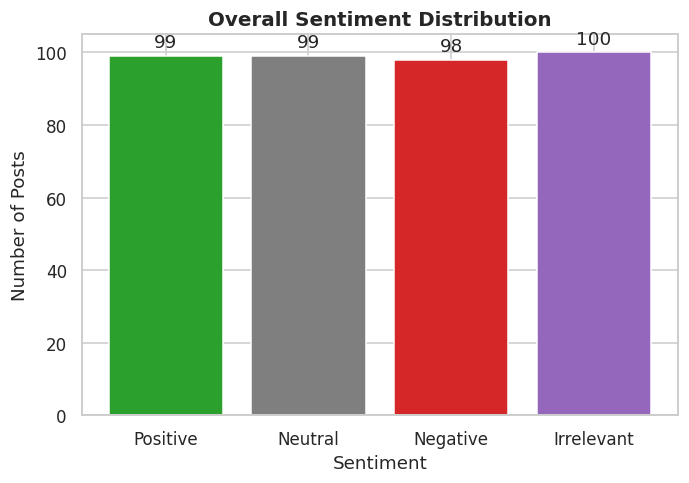

In [8]:
plot_sentiment_distribution(df)
plt.show()

### 4.2 Which entities/brands get talked about the most?

In [9]:
df['entity'].value_counts().head(10)

entity
Google           40
Cyberpunk2077    40
Amazon           40
Microsoft        40
CallOfDuty       40
PlayStation5     40
Xbox             39
Overwatch        39
Borderlands      39
Nvidia           39
Name: count, dtype: int64

### 4.3 Sentiment mix per entity

Volume alone doesn't tell us about *opinion* — let's look at the sentiment split for the most-discussed entities.

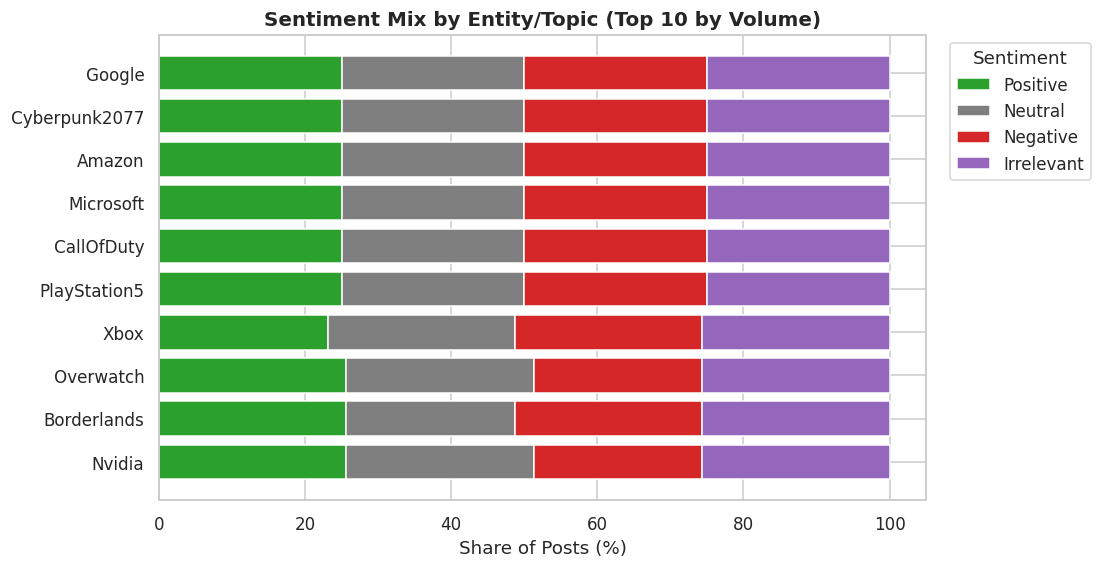

In [10]:
plot_entity_sentiment_stacked(df, top_n=10)
plt.show()

### 4.4 Who's winning, who's losing? Net sentiment score

We define **Net Sentiment = %Positive − %Negative** for each entity (ignoring Neutral/Irrelevant). A positive score means the public leans favorable; a negative score means the entity is more criticized than praised.

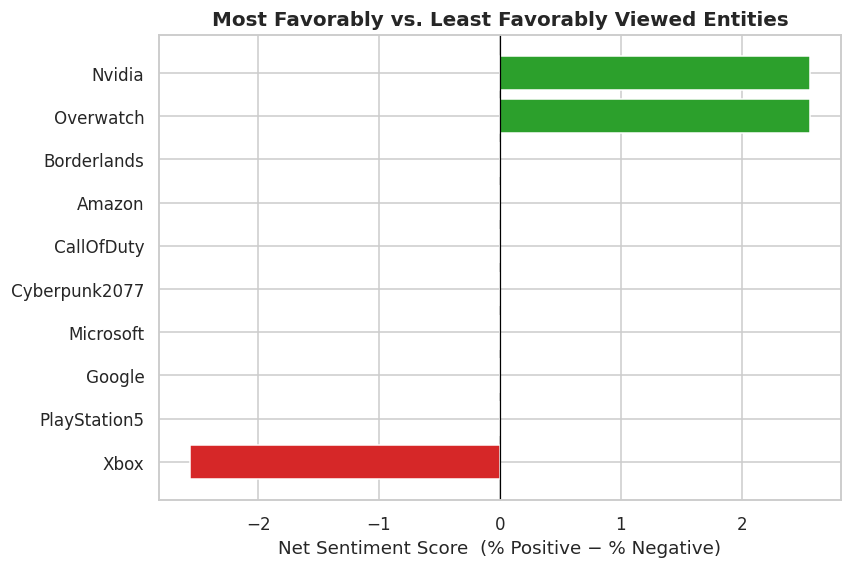

In [11]:
net_scores = net_sentiment_score(df)
plot_net_sentiment(net_scores, top_n=15)
plt.show()

### 4.5 Post length by sentiment

Do people write longer posts when they're upset? Let's check the cleaned word-count distribution per class.

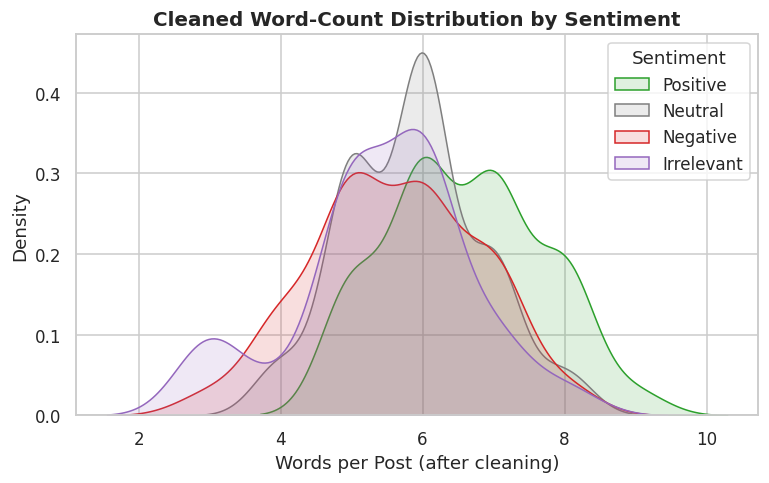

In [12]:
plot_text_length_distribution(df)
plt.show()

### 4.6 What words drive Positive vs. Negative sentiment?

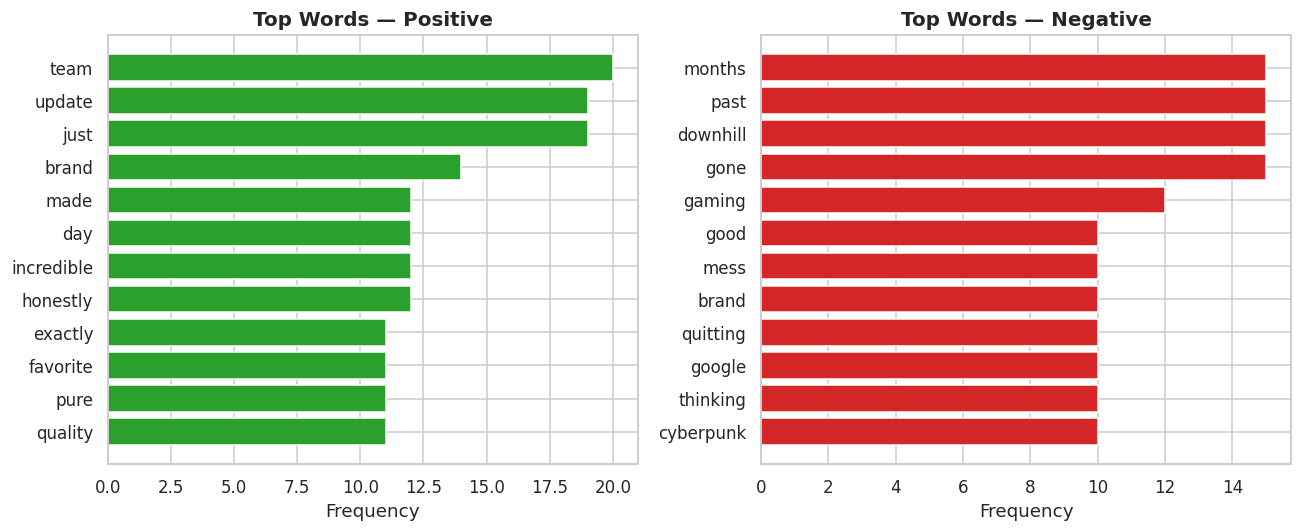

In [13]:
plot_top_words_by_sentiment(df, sentiments=("Positive", "Negative"), top_n=12)
plt.show()

### 4.7 Word cloud (optional)

Requires the `wordcloud` package (`pip install wordcloud`). This cell skips gracefully if it isn't installed — it just prints a note instead of erroring.

In [14]:
fig = generate_wordcloud(" ".join(df['clean_text']))
if fig is not None:
    plt.show()
else:
    print("Install the 'wordcloud' package to see this visualization: pip install wordcloud")

Install the 'wordcloud' package to see this visualization: pip install wordcloud


## 5. Bonus: cross-checking labels with lexicon-based sentiment (VADER)

Everything above uses the dataset's own human-labeled sentiment. As an optional sanity check, we can also score the *raw* text with VADER — a rule-based sentiment lexicon well-suited to short, informal social media text — and see how often it agrees with the human label. This only runs if `vaderSentiment` is installed; otherwise it prints a short note and moves on.

In [15]:
if vader_available():
    from src.sentiment_utils import agreement_with_vader
    vader_df = score_with_vader(df['text'])
    agreement = agreement_with_vader(df, vader_df)
    print(f"VADER agrees with the human label on {agreement:.1f}% of Positive/Negative/Neutral posts.")
else:
    print("vaderSentiment isn't installed in this environment, so this bonus check is skipped.")
    print("Install it with: pip install vaderSentiment")

vaderSentiment isn't installed in this environment, so this bonus check is skipped.
Install it with: pip install vaderSentiment


## 6. Key Insights

*(The bullet points below are written generally; the numbers printed in the cell after them reflect whichever dataset this notebook was last run against — the bundled sample by default. Re-run after downloading the full dataset for production-quality numbers.)*

- **Overall balance** — check the class split printed below; a skew toward one class affects how you should interpret raw counts elsewhere in the notebook.
- **Most-discussed entities** — see Section 4.2 for what the conversation volume looks like.
- **Most / least favorably viewed entities** — see the Net Sentiment ranking in Section 4.4; large negative scores are a signal worth investigating (e.g. an outage, a controversial update).
- **Language patterns** — see Section 4.6. Words like *love*, *great*, *amazing* tend to dominate Positive posts, while words like *crash*, *worst*, *unhelpful* tend to dominate Negative ones (exact words depend on the dataset in use).

In [16]:
print("Auto-generated summary stats for this run:\n")
print(f"Total posts analyzed: {len(df):,}")
print(f"Entities covered: {df['entity'].nunique()}")
print("\nOverall sentiment split:")
print((df['sentiment'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')
print(f"\nMost favorably viewed entity: {net_scores.idxmax()}  (net score: {net_scores.max():.1f})")
print(f"Most criticized entity:       {net_scores.idxmin()}  (net score: {net_scores.min():.1f})")

Auto-generated summary stats for this run:

Total posts analyzed: 396
Entities covered: 10

Overall sentiment split:
sentiment
Irrelevant    25.3%
Neutral       25.0%
Positive      25.0%
Negative      24.7%
Name: proportion, dtype: str

Most favorably viewed entity: Nvidia  (net score: 2.6)
Most criticized entity:       Xbox  (net score: -2.6)


## 7. Next Steps

- Swap in the full dataset (`python data/download_data.py`) for production-scale results
- Train a text classifier (e.g. TF-IDF + Logistic Regression, or a fine-tuned transformer) using the labeled sentiment as ground truth, and compare its accuracy against the VADER baseline above
- Track sentiment over time if timestamps become available, to catch shifts in public opinion around specific events or releases
- Drill into the `Irrelevant` class specifically — understanding what makes a post *not about* the entity can improve entity-extraction upstream
